In [ ]:
# Colab setup
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, random, matplotlib.pyplot as plt, itertools
import tensorflow as tf
print("TensorFlow:", tf.__version__)
SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)


Mounted at /content/drive
TensorFlow: 2.19.0


In [ ]:
# Create dataset folders
import os
base_dir = '/content/drive/MyDrive/art_styles'
os.makedirs(base_dir, exist_ok=True)
for split in ['train', 'val']:
    for style in ['Impressionism', 'Cubism', 'Surrealism']:
        os.makedirs(os.path.join(base_dir, split, style), exist_ok=True)
print("✅ Folders created successfully!")


✅ Folders created successfully!


In [ ]:
# Quick sanity check (counts)
import os

base_dir = '/content/drive/MyDrive/art_styles'
for split in ['train', 'val']:
    print(f"\n=== {split.upper()} DATA ===")
    for style in os.listdir(os.path.join(base_dir, split)):
        style_path = os.path.join(base_dir, split, style)
        count = len(os.listdir(style_path))
        print(f"{style:<15} → {count} images")



=== TRAIN DATA ===
Impressionism   → 25 images
Cubism          → 26 images
Surrealism      → 25 images

=== VAL DATA ===
Cubism          → 8 images
Surrealism      → 8 images
Impressionism   → 8 images


In [ ]:
# Load and preprocess the image dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (180, 180)
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    '/content/drive/MyDrive/art_styles/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    '/content/drive/MyDrive/art_styles/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 61 images belonging to 3 classes.
Found 15 images belonging to 3 classes.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = train_gen.num_classes

model = keras.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,363 (25.36 MB)

 Trainable params: 6,647,363 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.3034 - loss: 1.2323 - val_accuracy: 0.3333 - val_loss: 1.1028
Epoch 2/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 825ms/step - accuracy: 0.4297 - loss: 1.1168 - val_accuracy: 0.3333 - val_loss: 0.9911
Epoch 3/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 983ms/step - accuracy: 0.4600 - loss: 0.9302 - val_accuracy: 0.6000 - val_loss: 0.9268
Epoch 4/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 842ms/step - accuracy: 0.6494 - loss: 0.7915 - val_accuracy: 0.8667 - val_loss: 0.6890
Epoch 5/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 815ms/step - accuracy: 0.6505 - loss: 0.7094 - val_accuracy: 0.6000 - val_loss: 0.6686
Epoch 6/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 801ms/step - accuracy: 0.8209 - loss: 0.5205 - val_accuracy: 0.6667 - val_loss: 0.5949
Epoch 7/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8994 - loss: 0.2952 - val_accuracy: 0.4667 - val_loss: 1.1619
Epoch 8/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 820ms/step - accuracy: 0.9224 - loss: 0.2082 - val_accuracy: 0.7333 - val_loss: 0.61

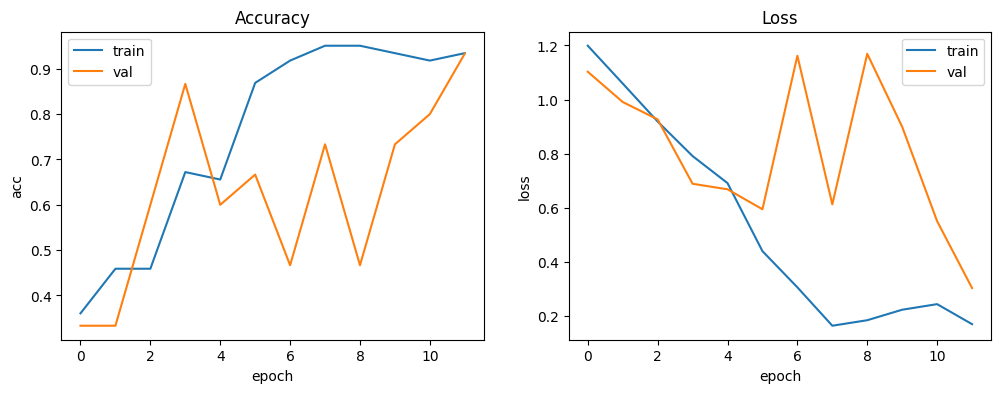

In [ ]:
EPOCHS = 12

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1
)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories
train_dir = '/content/drive/MyDrive/art_styles/train'
val_dir = '/content/drive/MyDrive/art_styles/val'

# Image generator (rescaling + simple augmentation)
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load dataset
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)


Found 76 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pretrained MobileNetV2 (transfer learning)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base layers

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  # 3 = number of art styles
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# quick evaluation
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"Validation accuracy: {val_acc:.3f} | loss: {val_loss:.3f}")

# class names (ordered the same way as generators)
class_names = list(train_gen.class_indices.keys())
class_names


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.1944 - loss: 1.4807
Validation accuracy: 0.167 | loss: 1.486


['Cubism', 'Impressionism', 'Surrealism']

Found 24 images belonging to 3 classes.
               precision    recall  f1-score   support

       Cubism       0.00      0.00      0.00         8
Impressionism       0.00      0.00      0.00         8
   Surrealism       0.21      0.50      0.30         8

     accuracy                           0.17        24
    macro avg       0.07      0.17      0.10        24
 weighted avg       0.07      0.17      0.10        24



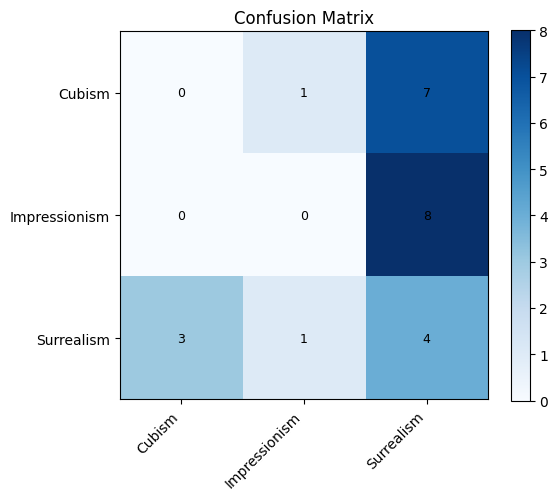

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, itertools

# rebuild a NON-shuffled validation generator for clean metrics
from tensorflow.keras.preprocessing.image import ImageDataGenerator
val_eval = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/content/drive/MyDrive/art_styles/val',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

# predictions
val_eval.reset()
probs = model.predict(val_eval, verbose=0)
y_pred = np.argmax(probs, axis=1)
y_true = val_eval.classes
labels = list(val_eval.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

# confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix"); plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()


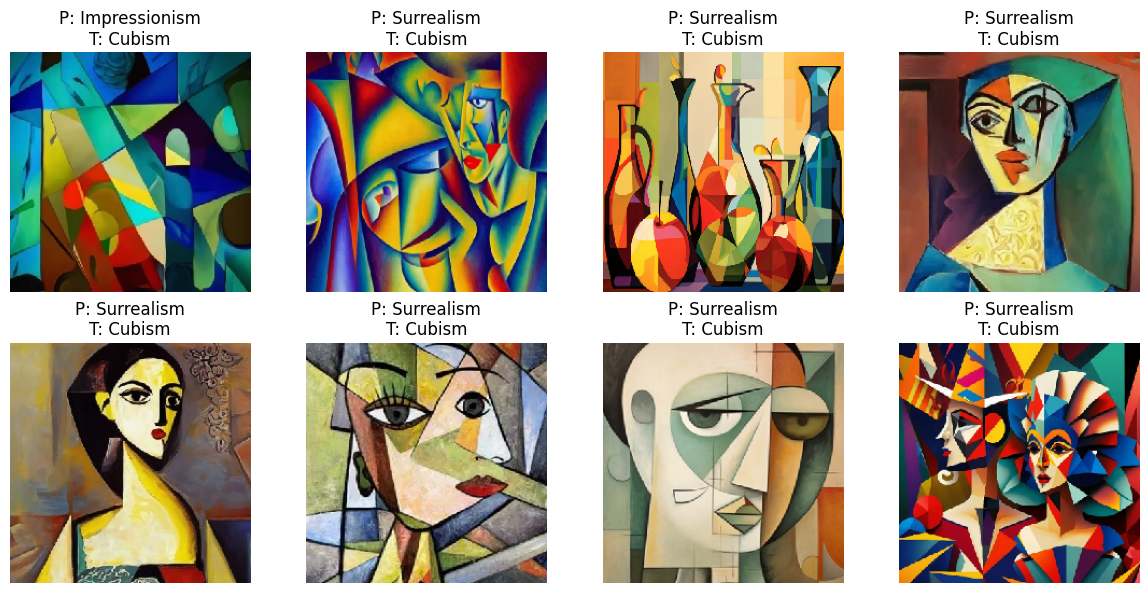

In [ ]:
# show 8 validation images with predicted vs true labels
batch_imgs, batch_labels = next(val_eval)
pred_idx = np.argmax(model.predict(batch_imgs, verbose=0), axis=1)
true_idx = np.argmax(batch_labels, axis=1)

plt.figure(figsize=(12,6))
for i in range(min(8, len(batch_imgs))):
    plt.subplot(2,4,i+1)
    plt.imshow((batch_imgs[i]*255).astype("uint8"))
    plt.axis("off")
    plt.title(f"P: {labels[pred_idx[i]]}\nT: {labels[true_idx[i]]}")
plt.tight_layout(); plt.show()


Saved model to: /content/drive/MyDrive/art_styles/mobilenetv2_art_styles.h5


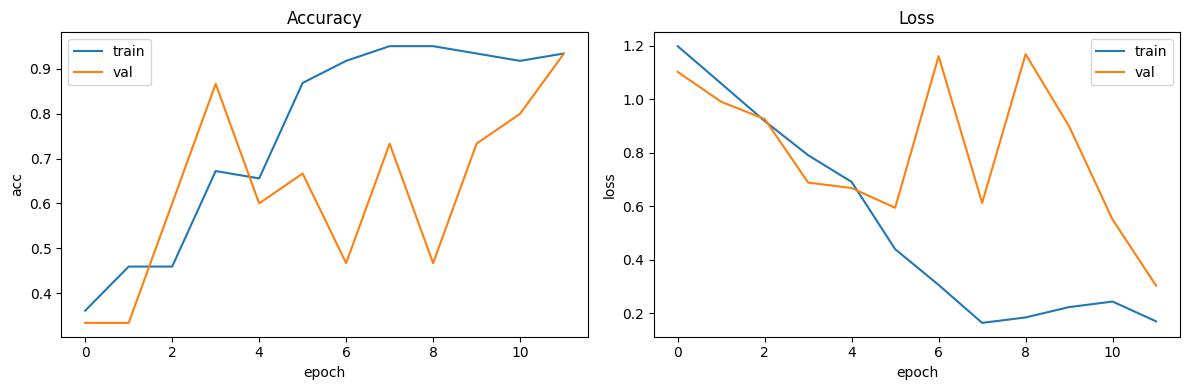

Saved curves to Drive.


In [ ]:
# save model
save_model_path = "/content/drive/MyDrive/art_styles/mobilenetv2_art_styles.h5"
model.save(save_model_path)
print("Saved model to:", save_model_path)

# (optional) save training curves if you still have 'history'
import matplotlib.pyplot as plt

def save_curves(h, out_png):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(h.history['accuracy']); plt.plot(h.history['val_accuracy'])
    plt.title('Accuracy'); plt.xlabel('epoch'); plt.ylabel('acc'); plt.legend(['train','val'])
    plt.subplot(1,2,2); plt.plot(h.history['loss']); plt.plot(h.history['val_loss'])
    plt.title('Loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(['train','val'])
    plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.show()

save_curves(history, "/content/drive/MyDrive/art_styles/training_curves.png")
print("Saved curves to Drive.")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3293 - loss: 1.3272 - val_accuracy: 0.6250 - val_loss: 0.7868
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 982ms/step - accuracy: 0.5791 - loss: 1.0199 - val_accuracy: 1.0000 - val_loss: 0.4092
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 768ms/step - accuracy: 0.7928 - loss: 0.5755 - val_accuracy: 1.0000 - val_loss: 0.2276
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 773ms/step - accuracy: 0.9677 - loss: 0.3060 - val_accuracy: 0.9583 - val_loss: 0.1446
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9418 - loss: 0.2736 - val_accuracy: 0.9583 - val_loss: 0.0981
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 796ms/step - accuracy: 0.9052 - loss: 0.2742 - val_accuracy: 0.9583 - val_loss: 0.0771
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 825ms/step - accuracy: 0.9469 - loss: 0.2335 - val_accuracy: 1.0000 - val_loss: 0.0556
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9819 - loss: 0.1249 - val_accuracy: 1.0000 - val_loss: 0.0467


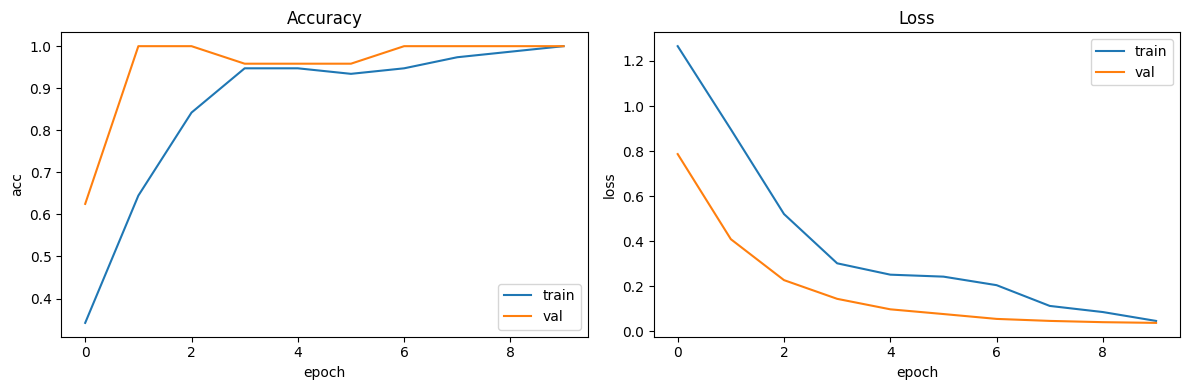

In [ ]:
# unfreeze top of backbone and fine-tune with a low LR
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

EPOCHS_FT = 10
history_ft = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_FT)

save_curves(history_ft, "/content/drive/MyDrive/art_styles/training_curves_finetune.png")
model.save("/content/drive/MyDrive/art_styles/mobilenetv2_art_styles_finetuned.h5")


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Path to a single test image (update this path to one of your uploaded images)
img_path = '/content/drive/MyDrive/art_styles/val/Impressionism/Screenshot (1870).png'

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Load your model
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/art_styles/mobilenetv2_art_styles.h5')

# Predict
pred = model.predict(img_array)
classes = ['Impressionism', 'Cubism', 'Surrealism']
predicted_class = classes[np.argmax(pred)]

print("✅ Predicted Style:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
✅ Predicted Style: Surrealism


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load your trained model
model_path = "/content/drive/MyDrive/art_styles/mobilenetv2_art_styles.h5"
model = tf.keras.models.load_model(model_path)

# Path to any test image (replace with one from your validation folder)
test_img_path = "/content/drive/MyDrive/art_styles/val/Cubism/Screenshot (1913).png"

# Load and preprocess the image
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
pred = model.predict(img_array)
class_names = ['Impressionism', 'Cubism', 'Surrealism']  # same as your folders
predicted_class = class_names[np.argmax(pred)]

print(f"🎨 The model predicts this artwork is in the style of: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 971ms/step
🎨 The model predicts this artwork is in the style of: Cubism


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step


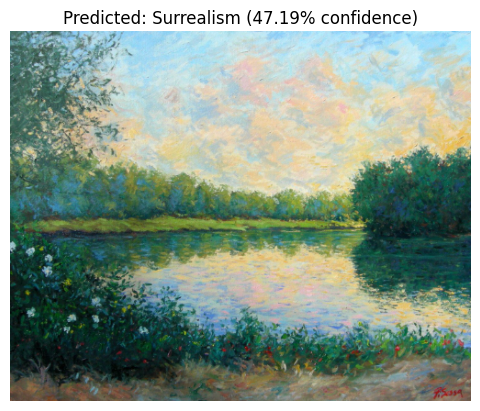

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load the trained model
model_path = "/content/drive/MyDrive/art_styles/mobilenetv2_art_styles.h5"
model = tf.keras.models.load_model(model_path)

# Path to one of your test images
test_img_path = "/content/drive/MyDrive/art_styles/val/Impressionism/Screenshot (1872).png"

# Load and preprocess
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
pred = model.predict(img_array)
class_names = ['Impressionism', 'Cubism', 'Surrealism']
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

# 🖼️ Display image and prediction
plt.imshow(image.load_img(test_img_path))
plt.axis("off")
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}% confidence)")
plt.show()


Classes: ['Cubism', 'Impressionism', 'Surrealism']
Found 24 images belonging to 3 classes.


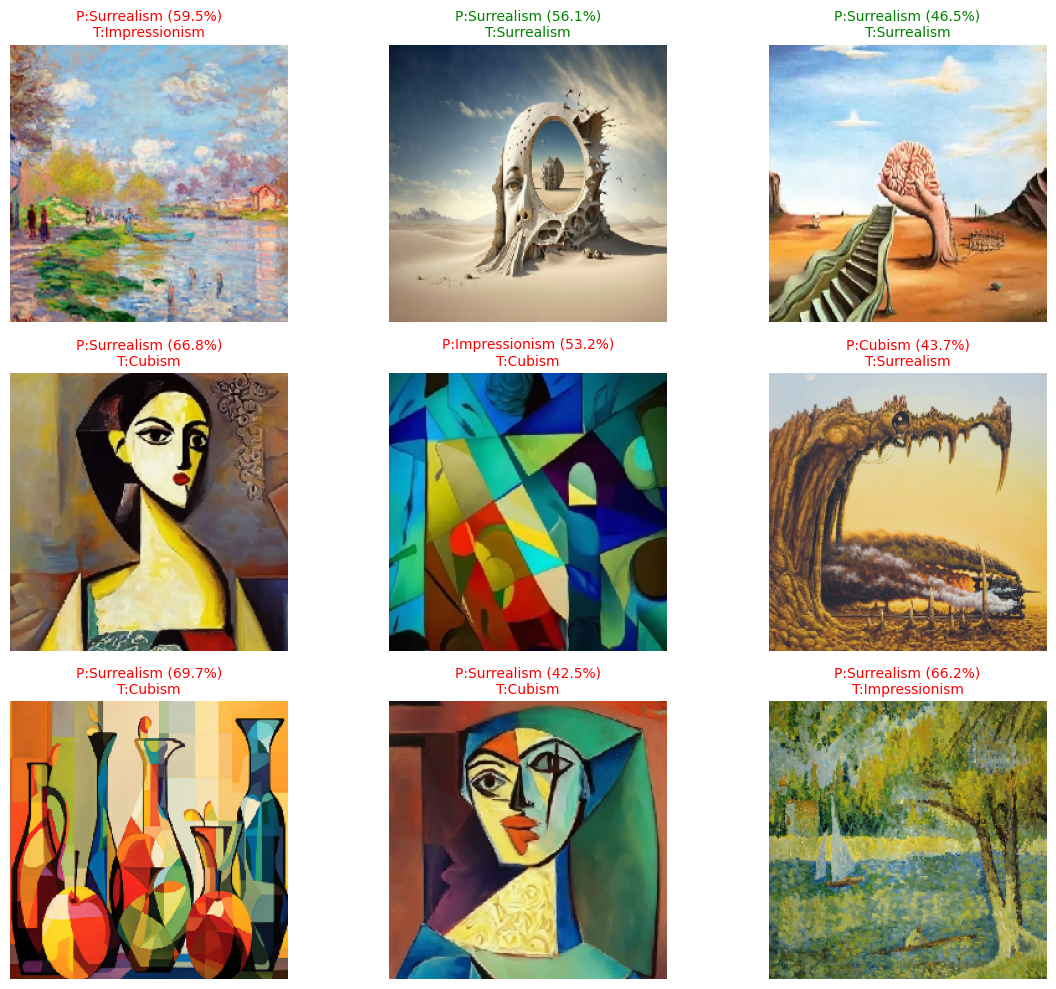

Saved grid to: /content/drive/MyDrive/art_styles/prediction_grid.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# ---- Prediction grid on random validation images ----
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# class names (taken from your folder order)
val_dir = "/content/drive/MyDrive/art_styles/val"
class_names = sorted(os.listdir(val_dir))  # ['Cubism','Impressionism','Surrealism'] maybe
print("Classes:", class_names)

# generator with shuffle=True to get a random batch
val_vis = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=12,        # grab up to 12 images
    class_mode='categorical',
    shuffle=True
)

imgs, labels_true = next(val_vis)
probs = model.predict(imgs, verbose=0)
pred_idx = probs.argmax(axis=1)
true_idx = labels_true.argmax(axis=1)

n = min(9, imgs.shape[0])    # show up to 3x3
rows, cols = 3, 3
plt.figure(figsize=(12, 10))

for i in range(n):
    plt.subplot(rows, cols, i+1)
    plt.imshow((imgs[i]*255).astype("uint8"))
    plt.axis('off')
    p = class_names[pred_idx[i]]
    t = class_names[true_idx[i]]
    conf = probs[i, pred_idx[i]]*100
    ok = (pred_idx[i] == true_idx[i])
    title = f"P:{p} ({conf:.1f}%)\nT:{t}"
    color = "green" if ok else "red"
    plt.title(title, color=color, fontsize=10)

plt.tight_layout()
plt.show()

# (optional) save to Drive for your report
out_path = "/content/drive/MyDrive/art_styles/prediction_grid.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved grid to:", out_path)


Found 24 images belonging to 3 classes.
               precision    recall  f1-score   support

       Cubism       0.00      0.00      0.00         8
Impressionism       0.00      0.00      0.00         8
   Surrealism       0.21      0.50      0.30         8

     accuracy                           0.17        24
    macro avg       0.07      0.17      0.10        24
 weighted avg       0.07      0.17      0.10        24



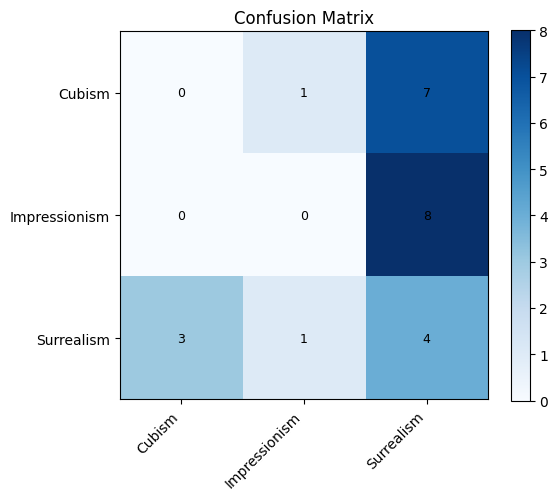

In [ ]:
# Classification report + confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# non-shuffled generator so labels align
val_eval = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)
probs_all = model.predict(val_eval, verbose=0)
y_pred = probs_all.argmax(axis=1)
y_true = val_eval.classes
labels = list(val_eval.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues"); plt.title("Confusion Matrix"); plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/art_styles/confusion_matrix.png", dpi=150)
plt.show()


In [ ]:
                                                                                      # ==== Single-image (or multi-image) upload & prediction ====
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os, io, sys

# 1) Load the trained model (uses the in-memory `model` if available; otherwise loads from Drive)
MODEL_PATH = "/content/drive/MyDrive/art_styles/mobilenetv2_art_styles.h5"
try:
    _ = model  # use the already-trained model in RAM if it exists
except NameError:
    import tensorflow as tf
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"Loaded model from: {MODEL_PATH}")

# 2) Get class names (prefer the same order as training)
if 'train_gen' in globals():
    class_names = list(train_gen.class_indices.keys())
else:
    # fallback: read from validation directory (ensure it matches your training classes)
    val_dir = "/content/drive/MyDrive/art_styles/val"
    class_names = sorted([d for d in os.listdir(val_dir) if os.path.isdir(os.path.join(val_dir, d))])
print("Classes:", class_names)

# 3) Upload one or more images
uploaded = files.upload()  # choose files from your computer
if not uploaded:
    print("No file uploaded."); sys.exit()

def preprocess_pil(img_pil, target_size=(224,224)):
    img = img_pil.convert("RGB").resize(target_size)
    arr = np.array(img).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=0)  # (1, H, W, 3)
    return img, arr

for fname, bytes_obj in uploaded.items():
    img_pil = Image.open(io.BytesIO(bytes_obj))
    img_show, x = preprocess_pil(img_pil, target_size=(224,224))
    probs = model.predict(x, verbose=0)[0]
    top3_idx = np.argsort(probs)[::-1][:3]
    pred_idx = top3_idx[0]
    pred_label = class_names[pred_idx]
    conf = probs[pred_idx] * 100

    # show image with predicted label
    plt.imshow(img_show)
    plt.axis("off")
    plt.title(f"Predicted: {pred_label} ({conf:.2f}%)")
    plt.show()

    # print top-3 probabilities
    print("Top-3 predictions:")
    for i in top3_idx:
        print(f"  {class_names[i]:15s} : {probs[i]*100:.2f}%")
    print("-" * 40)


Classes: ['Cubism', 'Impressionism', 'Surrealism']


TypeError: 'NoneType' object is not subscriptable